<a href="https://colab.research.google.com/github/paulocesardev8/descomplica-faculdade/blob/main/Atividade_Pr%C3%A1tica_6_%E2%80%93_Constru%C3%A7%C3%A3o_e_Avalia%C3%A7%C3%A3o_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [ ]:
# Criação e manipulação da base de dados

np.random.seed(42)
meses = np.arange(1, 25)
vendas = np.random.normal(200, 50, 24)
eventos = np.random.choice([0, 1], size=24)


df_vendas = pd.DataFrame({
    'Mês': meses,
    'Vendas': vendas,
    'Evento': eventos
})

df_vendas.head()

,Mês,Vendas,Evento
0,1,224.835708,1
1,2,193.086785,0
2,3,232.384427,0
3,4,276.151493,0
4,5,188.292331,0


In [ ]:
# Divisão dos dados

X_vendas = df_vendas[['Mês', 'Evento']]
y_vendas = df_vendas['Vendas']

X_train_vendas, X_test_vendas, y_train_vendas, y_test_vendas = train_test_split(X_vendas, y_vendas, test_size=0.3, random_state=42)

Erro Médio Quadrático (MSE): 3048.9676839648832
Coeficiente de Determinação (R²): -1.103641785560324


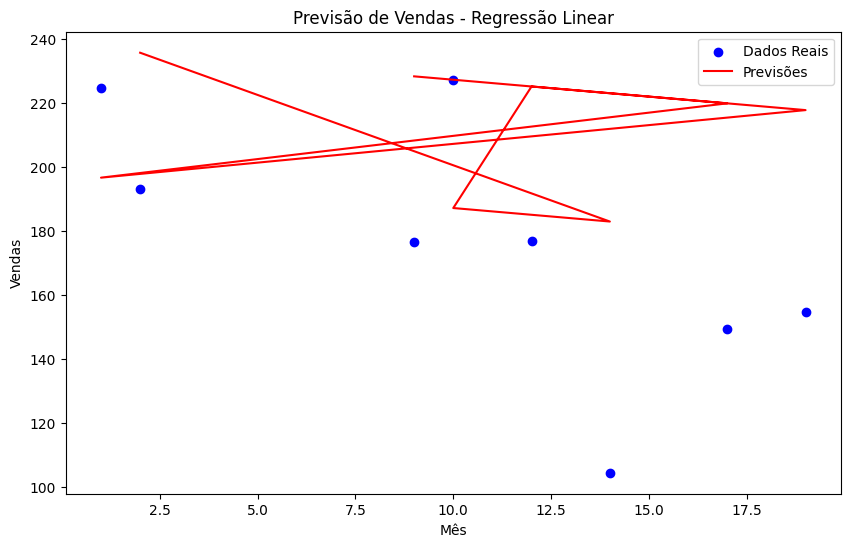

In [ ]:
# Construção e Avaliação do modelo

model_vendas = LinearRegression()
model_vendas.fit(X_train_vendas, y_train_vendas)

y_pred_vendas = model_vendas.predict(X_test_vendas)

mse_vendas = mean_squared_error(y_test_vendas, y_pred_vendas)
r2_vendas = r2_score(y_test_vendas, y_pred_vendas)

print(f'Erro Médio Quadrático (MSE): {mse_vendas}')
print(f'Coeficiente de Determinação (R²): {r2_vendas}')

plt.figure(figsize=(10, 6))
plt.scatter(X_test_vendas['Mês'], y_test_vendas, color='blue', label='Dados Reais')
plt.plot(X_test_vendas['Mês'], y_pred_vendas, color='red', label='Previsões')
plt.title('Previsão de Vendas - Regressão Linear')
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [ ]:
# PARTE 2 - Detecção de fraudes

np.random.seed(42)
valores = np.random.normal(1000, 200, 1000)

locais = np.random.choice(['Local_A', 'Local_B', 'Local_C'], size=1000)
fraudes = np.random.choice([0, 1], size=1000)  # 0 = Não fraude, 1 = Fraude

df_fraudes = pd.DataFrame({
    'Valores': valores,
    'Locais': locais,
    'Fraude': fraudes
})

In [ ]:
# Pré-processamento dos dados

df_fraudes = pd.get_dummies(df_fraudes, columns=['Locais'])
X_fraudes = df_fraudes.drop('Fraude', axis=1)
y_fraudes = df_fraudes['Fraude']
X_train_fraudes, X_test_fraudes, y_train_fraudes, y_test_fraudes = train_test_split(X_fraudes, y_fraudes, test_size=0.3, random_state=42)

In [ ]:
# Construção e avaliação de modelo

model_fraudes = LogisticRegression()
model_fraudes.fit(X_train_fraudes, y_train_fraudes)
y_pred_fraudes = model_fraudes.predict(X_test_fraudes)
accuracy_fraudes = accuracy_score(y_test_fraudes, y_pred_fraudes)
confusion = confusion_matrix(y_test_fraudes, y_pred_fraudes)
report = classification_report(y_test_fraudes, y_pred_fraudes)
print(f'Acurácia do modelo: {accuracy_fraudes}')
print('Matriz de Confusão:')
print(confusion)
print('Relatório de Classificação:')
print(report)

Acurácia do modelo: 0.49666666666666665
Matriz de Confusão:
[[120  23]
 [128  29]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.48      0.84      0.61       143
           1       0.56      0.18      0.28       157

    accuracy                           0.50       300
   macro avg       0.52      0.51      0.45       300
weighted avg       0.52      0.50      0.44       300

